In [53]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(str(Path.cwd()))
from src.database import DatabaseManager

In [54]:
def prepare_eda_data(df, feature_cols, target_col='label'):
    """
    Creates a temporary DF for plotting:
    1. Removes infinite values
    2. Clips outliers (1st/99th percentile) to make charts readable
    """
    plot_df = df[feature_cols + [target_col]].copy()
    
    # Handle infinite values usually caused by division by zero in ratios
    # plot_df.replace([float('inf'), -float('inf')], pd.NA, inplace=True)
    # plot_df.dropna(inplace=True)
    
    # Clip outliers for cleaner visualization
    for col in feature_cols:
        lower = plot_df[col].quantile(0.01)
        upper = plot_df[col].quantile(0.99)
        plot_df[col] = plot_df[col].clip(lower, upper)
        
    return plot_df

In [55]:
# Load parquet file
parquet_path = 'data/ml/training_dataset_final.parquet'
df = pd.read_parquet(parquet_path)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")
df.head()

Total rows: 31,016

Columns: ['trade_id', 'ticker', 'entry_date', 'entry_price', 'exit_date', 'exit_price', 'return_pct', 'days_held', 'exit_reason', 'label', 'max_drawdown_pct', 'max_favorable_excursion_pct', 'r_multiple', 'sharpe_ratio', 'initial_risk_pct', 'Close', 'Volume', 'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'Breakout', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'RSI_Regime', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'nATR_Lag1', 'ATR_Lag1', 'VCP_Ratio_Lag1', 'Consolidation_Width_Lag1', 'Price_vs_SMA_50_Lag1', 'Price_vs_SMA_150_Lag1', 'Price_vs_SMA_200_Lag1', 'RS_Lag1', 'RS_MA_Lag1', 'Dry_Up_Volume_Lag1', 'High_52W_Lag1', 'Low_52W_Lag1', 'RSI_14_Lag1', 'Dist_From_52W_High_Lag1', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 

,trade_id,ticker,entry_date,entry_price,exit_date,exit_price,return_pct,days_held,exit_reason,label,max_drawdown_pct,max_favorable_excursion_pct,r_multiple,sharpe_ratio,initial_risk_pct,Close,Volume,SMA_50,Price_vs_SMA_50,SMA_150,Price_vs_SMA_150,SMA_200,Price_vs_SMA_200,ATR,High_52W,Low_52W,Vol_MA,Vol_Ratio,High_20D,Breakout,RS,RS_MA,nATR,VCP_Ratio,Consolidation_Width,Dry_Up_Volume,RSI_14,RSI_Regime,Dist_From_52W_High,Is_Green_Day,Green_Days_Ratio_20D,SMA_50_Slope,nATR_Lag1,ATR_Lag1,VCP_Ratio_Lag1,Consolidation_Width_Lag1,Price_vs_SMA_50_Lag1,Price_vs_SMA_150_Lag1,Price_vs_SMA_200_Lag1,RS_Lag1,RS_MA_Lag1,Dry_Up_Volume_Lag1,High_52W_Lag1,Low_52W_Lag1,RSI_14_Lag1,Dist_From_52W_High_Lag1,alpha001,alpha006,alpha009,alpha012,alpha041,alpha101,alpha002,alpha004,alpha011,alpha013,alpha015,alpha054,alpha060,fiscal_date,filing_date_matched,fiscal_period,revenue_growth_yoy,net_income_growth_yoy,eps_growth_yoy,eps_accel,revenue_accel,inventory_growth_yoy,inventory_vs_sales_spread,symbol,reportedCurrency,cik,accepted_date,fiscalYear,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,statement_type,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid,debt_to_equity,current_ratio,quick_ratio,gross_margin,operating_margin,roe,roa,days_since_report,days_since_earnings,is_stale,has_fundamentals,pe_ratio,ps_ratio,pb_ratio,peg_adjusted,is_declining_earnings,date
0,1,ADSK,2003-04-02,8.195,2003-04-03,8.215,0.244051,1,trend_break,0,-4.820012,0.671141,None,NaN,None,8.195,5248400,7.3487,11.516323,6.998600,17.094848,6.821125,20.141472,0.321429,10.8975,5.45,2819824.00,1.861251,7.89,True,0.092998,0.085369,3.922252,1.026964,17.693716,1.382781,68.362832,1,-24.79926

In [57]:
# Updated list based on your specific column names
features_to_analyze = [
    # --- TREND & GEOMETRY ---
    'Price_vs_SMA_200',        # Primary Trend Filter
    'Dist_From_52W_High',      # How close is the breakout?
    'SMA_50_Slope',            # Is the trend accelerating?

    # --- VOLATILITY (VCP) ---
    'nATR',                    # Normalized volatility (The "Tightness")
    'VCP_Ratio',               # Specific VCP metric
    'Consolidation_Width',     # Base depth

    # --- MOMENTUM & VOLUME ---
    'RSI_14',                  # Classical Momentum
    'RS',                      # Relative Strength (Minervini key)
    'Vol_Ratio',               # Supply/Demand (Likely your Relative Volume)
    'Dry_Up_Volume',           # Lack of sellers

    # --- FUNDAMENTALS (GROWTH & QUALITY) ---
    'eps_growth_yoy',          # Earnings Momentum
    'revenue_accel',           # Sales Acceleration (Canslim nuance)
    'peg_adjusted',            # Valuation
    'inventory_vs_sales_spread', # Quality check (Inventory rising faster than sales is bad)

    # --- ALPHAS ---
    'alpha004',                # The mean reversion alpha you mentioned
    'alpha101'                 # WorldQuant alpha
]

# Create the cleaned dataframe for plotting
eda_df = prepare_eda_data(df, features_to_analyze)
eda_df.head()



,Price_vs_SMA_200,Dist_From_52W_High,SMA_50_Slope,nATR,VCP_Ratio,Consolidation_Width,RSI_14,RS,Vol_Ratio,Dry_Up_Volume,eps_growth_yoy,revenue_accel,peg_adjusted,inventory_vs_sales_spread,alpha004,alpha101,label
0,20.141472,-14.661434,0.057894,3.922252,1.026964,17.693716,68.362832,0.092998,1.861251,1.382781,-117.743590,-4.155762,NaN,NaN,-9.0,0.692488,0
1,49.799938,-2.229931,-0.046134,3.848382,1.060066,27.876330,78.561151,0.223899,1.525024,0.809324,226.530612,6.918884,0.544352,NaN,-9.0,0.840336,0
2,19.105970,0.000000,0.143268,2.420145,1.037037,15.637860,78.461538,0.082728,1.458224,1.144289,253.888889,4.163434,0.450759,NaN,-9.0,0.760234,0
3,57.493543,0.000000,0.229145,3.066667,1.783784,29.066667,88.188976,0.042556,7.540727,3.024357,230.769231,55.264904,0.000000,NaN,-9.0,0.693069,0
4,17.482394,0.000000,0.197067,2.492629,1.193294,12.101313,76.595745,0.120971,1.968900,1.967339,33.333333,2.529162,1.599000,NaN,-9.0,0.828729,0


In [ ]:
# Plot loop
for feature in features_to_analyze:
    plt.figure(figsize=(10, 4))
    
    # Boxplot shows the median and quartiles
    sns.boxplot(x='label', y=feature, data=eda_df, showfliers=False, palette={'0': "#e74c3c", '1': "#2ecc71"})
    
    plt.title(f"Distribution of {feature} by Outcome", fontsize=14)
    plt.xlabel("Target (0 = Fail/Neutral, 1 = Superperformer)")
    plt.show()
    
# 1. Calculate Correlation Matrix
corr_matrix = eda_df[features_to_analyze].corr()

# 2. Plot Heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide top triangle

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, center=0)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

In [64]:
features_to_analyze = [
    # --- TECHNICAL TREND (Geometry) ---
    'Price_vs_SMA_50',
    'Price_vs_SMA_150',
    'Price_vs_SMA_200',
    'Dist_From_52W_High',
    'SMA_50_Slope',
    'RS',                   # Relative Strength
    'RS_MA',                # Moving Average of RS
    'Is_Green_Day',         # Binary: 1 if close > open
    'Green_Days_Ratio_20D', # Buying pressure

    # lagged
    'nATR_Lag1', 'ATR_Lag1', 'VCP_Ratio_Lag1', 'Consolidation_Width_Lag1', 
    'Price_vs_SMA_50_Lag1', 'Price_vs_SMA_150_Lag1', 'Price_vs_SMA_200_Lag1', 'RS_Lag1', 
    'RS_MA_Lag1', 'Dry_Up_Volume_Lag1', 'High_52W_Lag1', 'Low_52W_Lag1', 'RSI_14_Lag1', 'Dist_From_52W_High_Lag1',
    
    # --- VOLATILITY & VCP (The Setup) ---
    'nATR',
    'VCP_Ratio',
    'Consolidation_Width',
    'Vol_Ratio',            # Relative Volume
    'Dry_Up_Volume',        # Binary or Ratio indicating lack of sellers

    # --- MOMENTUM ---
    'RSI_14',
    'RSI_Regime',           # Cardwell Regime (Binary or Categorical)

    # --- ALPHAS (WorldQuant / Custom) ---
    'alpha001', 'alpha002', 'alpha004', 'alpha006', 
    'alpha009', 'alpha011', 'alpha012', 'alpha013', 
    'alpha015', 'alpha041', 'alpha054', 'alpha060', 
    'alpha101',

    # --- FUNDAMENTAL GROWTH (Momentum) ---
    'eps_growth_yoy',
    'revenue_growth_yoy',
    'net_income_growth_yoy',
    'eps_accel',            # Change in growth rate (Second Derivative)
    'revenue_accel',
    'inventory_growth_yoy', 

    # --- FUNDAMENTAL RATIOS (Quality & Value) ---
    'peg_adjusted',
    'pe_ratio',
    'ps_ratio',
    'pb_ratio',
    'debt_to_equity',
    'current_ratio',
    'quick_ratio',
    'gross_margin',
    'operating_margin',
    'roe',
    'roa',
    # 'roic',
    # 'reinvestment_rate',
    # 'operating_leverage',
    # 'efficient_growth',     # Likely (Rev Growth * Margin)
    # 'accruals_ratio',       # Earnings Quality check

    # --- SPECIFIC SEPA CHECKS ---
    'inventory_vs_sales_spread', # CRITICAL: If Inventory > Sales, usually bad
    'days_since_earnings',       # EPS Surprise fade effect
    'days_since_report'
]
eda_df = prepare_eda_data(df, features_to_analyze)

C:\Users\Hang\AppData\Local\Temp\ipykernel_29256\4094340201.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(30), x='Importance', y='Feature', palette='viridis')


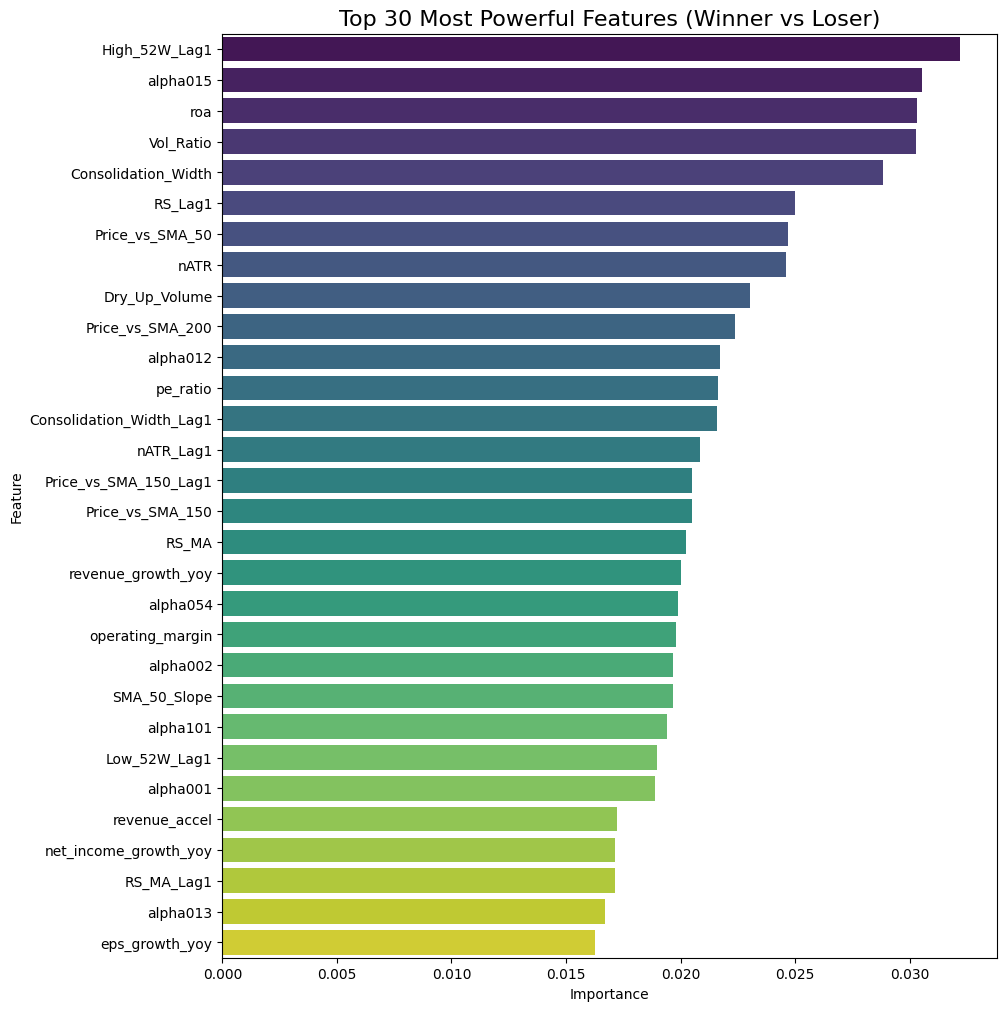

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Clean Data
analysis_df = prepare_eda_data(df, features_to_analyze)

# 2. Fit a quick Random Forest to see what matters
X = analysis_df[features_to_analyze]
y = analysis_df['label']

# Simple clean up for the quick test
X = X.fillna(0) 

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

# 3. Plot Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'Feature': features_to_analyze,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance.head(30), x='Importance', y='Feature', palette='viridis')
plt.title("Top 30 Most Powerful Features (Winner vs Loser)", fontsize=16)
plt.show()

In [69]:
import numpy as np

# ... (Previous code defining features_to_analyze) ...

# ==========================================
# 2. CREATE CLEAN TRAINING DATA (Robust)
# ==========================================

# Filter columns that actually exist
valid_features = [c for c in features_to_analyze if c in df.columns]

X = df[valid_features].copy()
y = df['label'].copy()

# --- THE FIX STARTS HERE ---

# 1. Replace Positive/Negative Infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Now Fill NaNs with 0 (or median if you prefer)
X = X.fillna(0)

# 3. Safety Clip: Cap values to avoid "Too Large for Float32" error
# (Some ratios can explode to 10^20, which breaks XGBoost/sklearn)
X = X.clip(lower=-1e8, upper=1e8)

# --- THE FIX ENDS HERE ---

print(f"✅ Data Cleaned: Infinity removed and values clipped.")

# ==========================================
# 3. RUN IMPORTANCE
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clean.fit(X, y)

# ... (Continue with plotting code)

✅ Data Cleaned: Infinity removed and values clipped.


,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


C:\Users\Hang\AppData\Local\Temp\ipykernel_29256\3497459284.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_stable.head(30), x='Importance', y='Feature', palette='viridis')


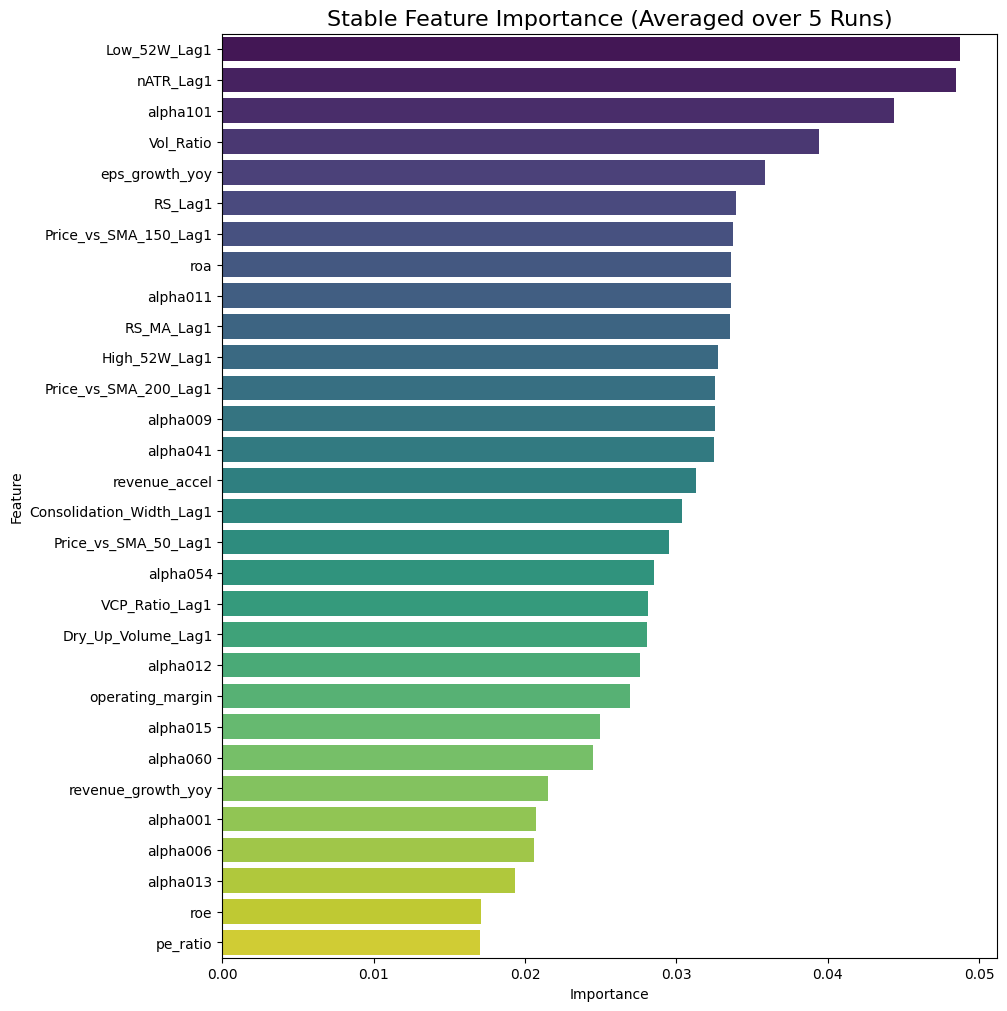

In [70]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Run the model 5 times with different seeds to average out the noise
importances_list = []

for seed in [42, 100, 2023, 7, 99]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=seed, n_jobs=-1)
    rf.fit(X, y)
    importances_list.append(rf.feature_importances_)

# Average the results
avg_importance = np.mean(importances_list, axis=0)

# Create the final stable dataframe
importance_stable = pd.DataFrame({
    'Feature': X.columns,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)

# This plot will be much more stable
plt.figure(figsize=(10, 12))
sns.barplot(data=importance_stable.head(30), x='Importance', y='Feature', palette='viridis')
plt.title("Stable Feature Importance (Averaged over 5 Runs)", fontsize=16)
plt.show()

✅ Data Cleaned: Infinity removed and values clipped.
✅ Ready for Training!
   Feature Count: 39
   Leaked Features Removed: 'nATR', 'RS', 'Price_vs_SMA_50'


C:\Users\Hang\AppData\Local\Temp\ipykernel_29256\237289247.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_clean.head(30), x='Importance', y='Feature', palette='viridis')


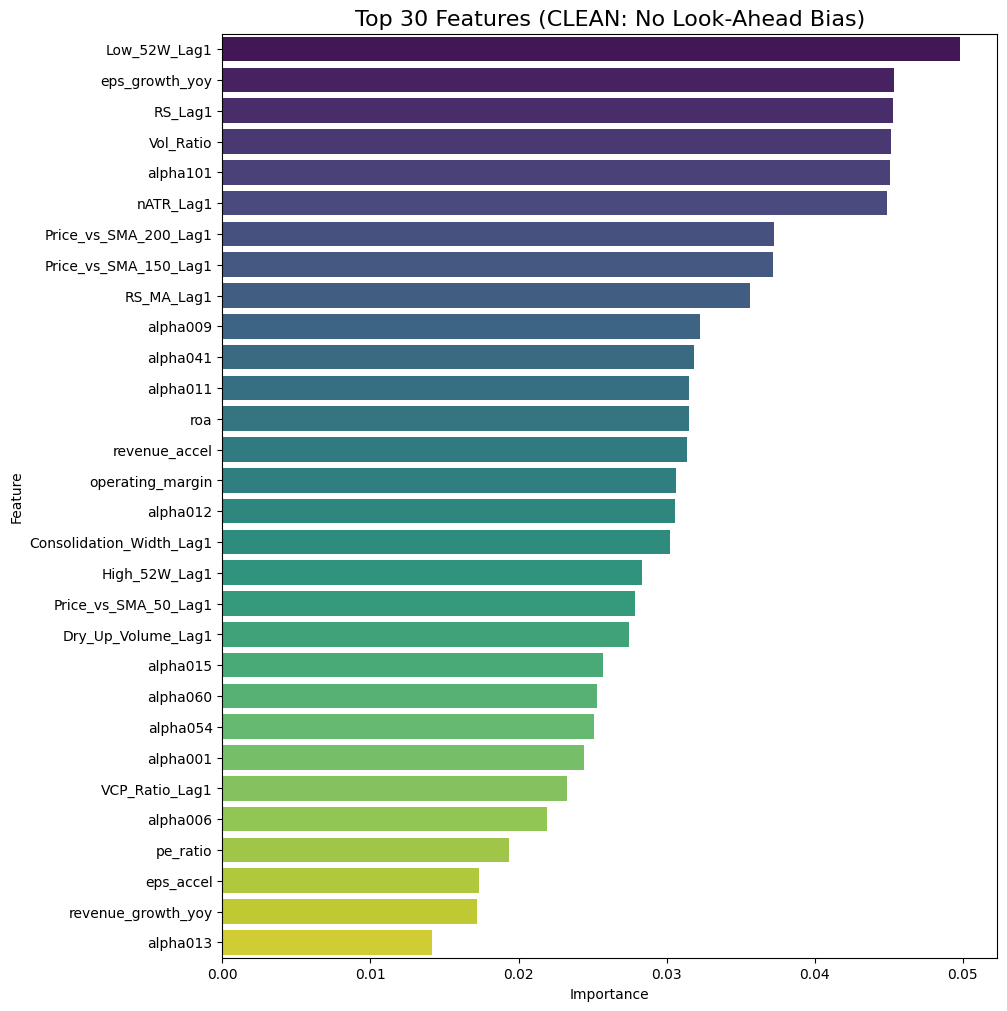

In [72]:
# ==========================================
# 1. DEFINE THE CLEAN FEATURE LIST
# ==========================================
# This list enforces the "Hybrid" Logic: 
# - Setup features are LAGGED (T-1)
# - Trigger features are CURRENT (Day T)
# ==========================================

features_to_analyze = [
    # --- THE SETUP (Lagged T-1) ---
    # These describe the "Quiet" base before the move.
    'nATR_Lag1',                # The most critical VCP metric
    'VCP_Ratio_Lag1',           # Volatility Contraction
    'Consolidation_Width_Lag1', # Base geometry
    'RS_Lag1',                  # Relative Strength Rank (Leader status)
    'RS_MA_Lag1',               # Trend of RS
    'Price_vs_SMA_50_Lag1',     # Trend extension
    'Price_vs_SMA_150_Lag1',
    'Price_vs_SMA_200_Lag1',
    'RSI_14_Lag1',              # Momentum context
    'Dry_Up_Volume_Lag1',       # Supply exhaustion
    'Dist_From_52W_High_Lag1',  # Proximity to high
    'High_52W_Lag1',            # Context
    'Low_52W_Lag1',

    # --- THE TRIGGER (Current Day T) ---
    # These describe the "Force" of the breakout today.
    'Vol_Ratio',                # The Explosion (Volume > 2x)
    # 'Breakout',               # Optional: If you have a binary flag
    
    # --- ALPHAS (Current Day T) ---
    # Fast signals describing immediate money flow.
    'alpha015', 'alpha041', 'alpha012', 'alpha101', 
    'alpha054', 'alpha001', 'alpha011', 'alpha013',
    'alpha060', 'alpha002', 'alpha004', 'alpha009', 'alpha006',

    # --- FUNDAMENTALS (Current/Recent) ---
    # These don't change daily, so "Current" is fine.
    'eps_growth_yoy', 'eps_accel',
    'revenue_growth_yoy', 'revenue_accel',
    'operating_margin', 'roe', 'roa',
    'pe_ratio', 'peg_adjusted',
    'debt_to_equity', 'current_ratio',
    'inventory_vs_sales_spread'
]

# ==========================================
# 2. CREATE CLEAN TRAINING DATA
# ==========================================
valid_features = [c for c in features_to_analyze if c in df.columns]

X = df[valid_features].copy()
y = df['label'].copy()

# --- THE FIX STARTS HERE ---

# 1. Replace Positive/Negative Infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Now Fill NaNs with 0 (or median if you prefer)
X = X.fillna(0)

# 3. Safety Clip: Cap values to avoid "Too Large for Float32" error
# (Some ratios can explode to 10^20, which breaks XGBoost/sklearn)
X = X.clip(lower=-1e8, upper=1e8)

# --- THE FIX ENDS HERE ---

print(f"✅ Data Cleaned: Infinity removed and values clipped.")

print(f"✅ Ready for Training!")
print(f"   Feature Count: {len(valid_features)}")
print(f"   Leaked Features Removed: 'nATR', 'RS', 'Price_vs_SMA_50'")

# ==========================================
# 3. RUN IMPORTANCE AGAIN
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clean.fit(X, y)

# Plotting code...
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_clean = pd.DataFrame({
    'Feature': valid_features,
    'Importance': rf_clean.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance_clean.head(30), x='Importance', y='Feature', palette='viridis')
plt.title("Top 30 Features (CLEAN: No Look-Ahead Bias)", fontsize=16)
plt.show()

Total Trades: 31016
Losers/Neutral (0): 30900
Winners (1): 116
Winner Rate: 0.37%


C:\Users\Hang\AppData\Local\Temp\ipykernel_29256\1566178259.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette={'0': "#e74c3c", '1': "#2ecc71"})


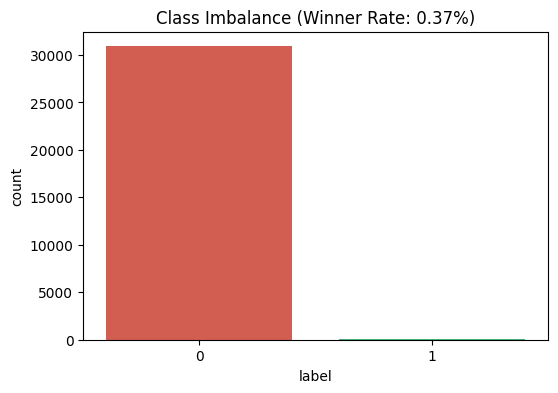

In [62]:
# 1. Calculate Class Imbalance
class_counts = df['label'].value_counts()
imbalance_ratio = class_counts[1] / class_counts.sum()

print(f"Total Trades: {len(df)}")
print(f"Losers/Neutral (0): {class_counts[0]}")
print(f"Winners (1): {class_counts[1]}")
print(f"Winner Rate: {imbalance_ratio:.2%}")

# Visualization of Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette={'0': "#e74c3c", '1': "#2ecc71"})
plt.title(f"Class Imbalance (Winner Rate: {imbalance_ratio:.2%})")
plt.show()

In [63]:
# 1. Define the top features
top_features = [
    'nATR', 
    'Price_vs_SMA_50', 
    'RS', 
    'Consolidation_Width', 
    'alpha015', 
    'Vol_Ratio', 
    'alpha041', 
    'Price_vs_SMA_200'
]
top_features = features_to_analyze
# 2. Prepare Data (Clip outliers for stats calculation)
stats_df = df[top_features + ['label']].copy()
for col in top_features:
    lower = stats_df[col].quantile(0.01)
    upper = stats_df[col].quantile(0.99)
    stats_df[col] = stats_df[col].clip(lower, upper)

# 3. Calculate Median Comparison
stats_comparison = stats_df.groupby('label')[top_features].median().T
stats_comparison.columns = ['Loser_Median', 'Winner_Median']

# 4. Calculate "Lift" (% Difference)
stats_comparison['%_Difference'] = (
    (stats_comparison['Winner_Median'] - stats_comparison['Loser_Median']) / 
    stats_comparison['Loser_Median'].abs()
) * 100

print(f"Comparing {len(df[df['label']==0])} Losers vs {len(df[df['label']==1])} Winners")
print("-" * 60)

# Display without the .style accessor to avoid the error
stats = stats_comparison.sort_values(by='%_Difference', key=abs, ascending=False)
display(stats)

Comparing 30900 Losers vs 116 Winners
------------------------------------------------------------


,Loser_Median,Winner_Median,%_Difference
eps_accel,2.044160,-5.000000,-344.599303
eps_growth_yoy,11.538462,-23.376623,-302.597403
net_income_growth_yoy,11.963707,-22.872881,-291.185558
Dist_From_52W_High_Lag1,-0.714884,-2.569182,-259.384357
revenue_accel,1.098472,3.276832,198.308117
Price_vs_SMA_200,22.566235,58.333213,158.497771
Price_vs_SMA_150,18.539669,46.863053,152.771795
Price_vs_SMA_150_Lag1,15.156270,36.737690,142.392689
Price_vs_SMA_200_Lag1,19.016383,45.932977,141.544238
SMA_50_Slope,0.202855,0.488971,141.044400


In [4]:
# ==============================================================================
# 1. DATA QUALITY AUDIT
# ==============================================================================
print("--- 1. DATA SHAPE & TYPES ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")

print("\n--- 2. MISSING & INFINITE VALUES ---")
# Check for Infinite values (Common in Ratios)
inf_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print(f"Total Infinite Values: {inf_count}")

# Check for Missing Values by Column (Top 20 offenders)
missing = df.isnull().mean() * 100
print("Top 20 Columns with Missing Data (%):")
print(missing.sort_values(ascending=False).head(20))

# Check Missing Fundamentals over Time
# If you have a 'has_fundamentals' flag or a key col like 'eps_growth'
if 'eps_growth_yoy' in df.columns:
    df['year'] = pd.to_datetime(df['date']).dt.year
    missing_by_year = df.groupby('year')['eps_growth_yoy'].apply(lambda x: x.isnull().mean())
    print("\nMissing Fundamentals by Year (Check for early data gaps):")
    print(missing_by_year.head(5))
    print(missing_by_year.tail(5))

--- 1. DATA SHAPE & TYPES ---
Rows: 31016, Columns: 213
Date Range: 2003-04-02 00:00:00 to 2025-12-03 00:00:00

--- 2. MISSING & INFINITE VALUES ---
Total Infinite Values: 174
Top 20 Columns with Missing Data (%):
r_multiple                     100.000000
initial_risk_pct               100.000000
inventory_vs_sales_spread      100.000000
inventory_growth_yoy           100.000000
sharpe_ratio                    78.453056
peg_adjusted                    43.222853
pb_ratio                         6.857751
efficient_growth                 5.961439
pe_ratio                         5.597111
quick_ratio                      5.526180
current_ratio                    5.526180
ps_ratio                         5.049007
operating_leverage               4.900696
treasuryStock                    4.468661
accruals_ratio                   4.304230
netIncomeDeductions              4.072092
roic                             4.068868
roe                              4.059195
otherAdjustmentsToNetIncome   

In [25]:
"""
Polishes the raw Feature Matrix before training.
Handles Infinites, NaNs, and Garbage Columns.
"""
print(f"🧹 Starting Cleanup: {df.shape[0]} rows, {df.shape[1]} cols")

# 1. DATE HANDLING
# Ensure date is strictly datetime (crucial for merges)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['ticker', 'date'])

# 2. THE "INFINITY" TRAP (Division by Zero)
# Ratios like P/E or Vol_Ratio often produce np.inf
# We replace them with NaN first, then handle NaNs globally
df = df.replace([np.inf, -np.inf], np.nan)

# 3. GARBAGE COLUMN REMOVAL
# Drop columns that are > 90% empty (broken features)
# This automatically catches 'entry_vol_ratio' or 'quick_ratio' if the API failed
threshold = 0.9 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold)

# 4. CRITICAL MISSING DATA (The "Must-Haves")
# If we don't have Price or Volume, the row is useless. Drop it.
critical_cols = ['close', 'volume']
# Filter to only existing critical columns
existing_critical = [c for c in critical_cols if c in df.columns]
df = df.dropna(subset=existing_critical)

# 5. FUNDAMENTAL FILLING (The "Forward Fill" Logic)
# Fundamentals (EPS) only appear once per quarter.
# We must forward-fill them to daily rows.
# GroupBy is essential so AAPL data doesn't leak into MSFT.
fundy_cols = [c for c in df.columns if c not in ['date', 'ticker', 'label']]
df[fundy_cols] = df.groupby('ticker')[fundy_cols].ffill()

# 6. REMAINING NAN HANDLING
# After ffill, IPOs might still have NaNs at the start.
# Option A: Fill with 0 (Safe for Growth/Volume, Dangerous for Price)
# Option B: Drop (Stricter, better for ML) -> We choose Drop for Training
df = df.dropna()

# 7. DUPLICATE CHECK
df = df.drop_duplicates(subset=['date', 'ticker'])

🧹 Starting Cleanup: 31016 rows, 213 cols


In [32]:
# Check for Missing Values by Column (Top 10 offenders)
missing = df.isnull().mean() * 100
print("Top 10 Columns with Missing Data (%):")
print(missing.sort_values(ascending=False).head(10))

features = df.select_dtypes(include=['float'])

print(f"Total rows: {len(features):,}")
print(f"\nColumns: {list(features.columns)}")
print(f"\nShape: {features.shape}")

Top 10 Columns with Missing Data (%):
trade_id      0.0000
ticker        0.0000
entry_date    0.0000
entry_price   0.0000
exit_date     0.0000
exit_price    0.0000
return_pct    0.0000
days_held     0.0000
exit_reason   0.0000
label         0.0000
dtype: float64
Total rows: 26,923

Columns: ['entry_price', 'exit_price', 'return_pct', 'max_drawdown_pct', 'max_favorable_excursion_pct', 'sharpe_ratio', 'Close', 'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'Dist_From_52W_High', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 'alpha015', 'alpha054', 'alpha060', 'revenue_growth_yoy', 'net_income_growth_yoy', 'eps_growth_yoy', 'eps_accel', 'revenue_accel', 'depreciationAndAmortization', 't

In [45]:
# ==============================================================================
# 2. WINNER vs LOSER DISTRIBUTION (The Alpha Check)
# ==============================================================================
# Define features to analyze (The ones we engineered)
key_features = ['SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'Dist_From_52W_High', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 'alpha015', 'alpha054', 'alpha060', 'revenue_growth_yoy', 'net_income_growth_yoy', 'eps_growth_yoy', 'eps_accel', 'revenue_accel', 'depreciationAndAmortization', 'totalInvestments', 'ebit', 'netIncomeFromContinuingOperations', 'taxPayables', 'accountsReceivables', 'costOfRevenue', 'goodwillAndIntangibleAssets', 'costAndExpenses', 'otherNonCurrentAssets', 'researchAndDevelopmentExpenses', 'totalNonCurrentLiabilities', 'capitalLeaseObligationsNonCurrent', 'totalEquity', 'ebitda', 'netReceivables', 'accountPayables', 'incomeTaxExpense', 'minorityInterest', 'generalAndAdministrativeExpenses', 'totalDebt', 'deferredRevenue', 'otherLiabilities', 'intangibleAssets', 'inventory', 'totalOtherIncomeExpensesNet', 'bottomLineNetIncome', 'weightedAverageShsOutDil', 'additionalPaidInCapital', 'totalCurrentAssets', 'treasuryStock', 'prepaids', 'longTermDebt', 'revenue', 'otherPayables', 'sellingGeneralAndAdministrativeExpenses', 'deferredRevenueNonCurrent', 'netInterestIncome', 'totalLiabilities', 'nonOperatingIncomeExcludingInterest', 'totalStockholdersEquity', 'grossProfit', 'retainedEarnings', 'otherReceivables', 'deferredTaxLiabilitiesNonCurrent', 'capitalLeaseObligations', 'shortTermInvestments', 'interestExpense', 'totalNonCurrentAssets', 'otherTotalStockholdersEquity', 'accruedExpenses', 'netIncome', 'taxAssets', 'otherNonCurrentLiabilities', 'netDebt', 'interestIncome', 'propertyPlantEquipmentNet', 'netIncomeDeductions', 'otherCurrentLiabilities', 'eps', 'netIncomeFromDiscontinuedOperations', 'weightedAverageShsOut', 'accumulatedOtherComprehensiveIncomeLoss', 'cashAndShortTermInvestments', 'operatingIncome', 'longTermInvestments', 'capitalLeaseObligationsCurrent', 'commonStock', 'totalLiabilitiesAndTotalEquity', 'epsDiluted', 'preferredStock', 'otherAssets', 'incomeBeforeTax', 'otherCurrentAssets', 'cashAndCashEquivalents', 'operatingExpenses', 'otherAdjustmentsToNetIncome', 'totalPayables', 'sellingAndMarketingExpenses', 'totalCurrentLiabilities', 'otherExpenses', 'goodwill', 'totalAssets', 'shortTermDebt', 'debt_to_equity', 'current_ratio', 'quick_ratio', 'gross_margin', 'operating_margin', 'roe', 'roa', 'operating_leverage', 'roic', 'days_since_report', 'days_since_earnings', 'pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted']

# Filter list to existing columns
plot_feats = [f for f in key_features if f in df.columns]

print(f"\n--- 3. WINNER vs LOSER STATISTICS ---")
# Compare Means
stats = df.groupby('label')[plot_feats].mean().T
stats.columns = ['Loser_Avg', 'Winner_Avg']
stats['Diff_%'] = ((stats['Winner_Avg'] - stats['Loser_Avg']) / stats['Loser_Avg']) * 100
print(stats)


--- 3. WINNER vs LOSER STATISTICS ---
                      Loser_Avg  Winner_Avg      Diff_%
SMA_50               678.163037   61.211773  -90.973885
Price_vs_SMA_50       12.401298   30.970679  149.737393
SMA_150              587.626814   52.410312  -91.081021
Price_vs_SMA_150      24.141720   59.994580  148.509962
SMA_200              541.442198   49.036720  -90.943314
...                         ...         ...         ...
days_since_earnings   51.283400   84.767241   65.291773
pe_ratio              82.809591   25.279665  -69.472539
ps_ratio              12.592405   12.554842   -0.298303
pb_ratio               4.323359    4.483847    3.712122
peg_adjusted           3.295715    0.772154  -76.570982

[139 rows x 3 columns]


In [46]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
stats = stats.sort_values(by='Diff_%', key=abs, ascending=False)
stats.head(139)

,Loser_Avg,Winner_Avg,Diff_%
accountsReceivables,-2.114849e+07,5.654830e+08,-2773.868936
operating_margin,-3.082214e+01,-3.627448e+02,1076.897034
gross_margin,4.106500e+01,-1.070810e+02,-360.759707
roic,2.266782e+00,-4.458208e+00,-296.675636
epsDiluted,5.691100e-01,-1.052104e+00,-284.868290
eps,5.806418e-01,-1.047683e+00,-280.435323
deferredRevenueNonCurrent,-1.371197e+08,2.015988e+08,-247.023954
SMA_50_Slope,2.514782e-01,6.327154e-01,151.598498
Price_vs_SMA_50,1.240130e+01,3.097068e+01,149.737393
Price_vs_SMA_150,2.414172e+01,5.999458e+01,148.509962


In [41]:
FEATURE_GROUPS = {
    "Technicals": [
        'Price_vs_SMA_50', 'Price_vs_SMA_150', 'Price_vs_SMA_200', 'SMA_50_Slope',
        'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dist_From_52W_High',
        'RSI_14', 'Vol_Ratio', 'Dry_Up_Volume', 'Green_Days_Ratio_20D'
    ],
    "Alphas": [
        'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 
        'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 
        'alpha015', 'alpha054', 'alpha060'
    ],
    "Fundamental_Ratios": [
        'eps_growth_yoy', 'revenue_growth_yoy', 'eps_accel', 'revenue_accel',
        'debt_to_equity', 'current_ratio', 'quick_ratio', 
        'gross_margin', 'operating_margin', 'roe', 'roa', 'roic',
        'operating_leverage', 'pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted'
    ],
    "Metadata": [
        'days_since_report', 'is_stale', 'has_fundamentals', 'market_cap'
    ]
}

# Raw columns to check for missing data but exclude from ML plots
RAW_FINANCIALS = [
    'revenue', 'netIncome', 'totalAssets', 'totalDebt', 'inventory', 
    'cashAndCashEquivalents', 'operatingCashFlow', 'grossProfit'
    # ... (The rest of your 50+ raw columns)
]

def load_data():
    if not os.path.exists(DATA_PATH):
        print(f"❌ File not found: {DATA_PATH}")
        return None
    return pd.read_parquet(DATA_PATH)

def audit_data_quality(df):
    print("\n================ DATA QUALITY AUDIT ================")
    
    # 1. Check Fundamental Freshness
    if 'days_since_report' in df.columns:
        print("\n--- Fundamental Freshness (Days Since Report) ---")
        print(df['days_since_report'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
        
        stale_count = (df['days_since_report'] > 100).sum()
        print(f"⚠️ Rows with >100 day old data: {stale_count} ({stale_count/len(df):.1%})")
    
    # 2. Check for "Ghost" Zeros in Ratios
    print("\n--- Suspicious Zeros (Potential Missing Data) ---")
    cols_to_check = ['pe_ratio', 'debt_to_equity', 'roe']
    for col in cols_to_check:
        if col in df.columns:
            zeros = (df[col] == 0).sum()
            print(f"{col}: {zeros} zeros ({zeros/len(df):.1%})")

    # 3. Check Infinite Values
    print("\n--- Infinite Values (Division by Zero Errors) ---")
    num_df = df.select_dtypes(include=[np.number])
    inf_count = np.isinf(num_df).sum()
    print(inf_count[inf_count > 0])

def analyze_winner_separation(df):
    print("\n================ WINNER vs LOSER SEPARATION ================")
    
    if 'label' not in df.columns:
        print("❌ No 'label' column found. Cannot analyze separation.")
        return

    # Combine interesting features
    analysis_cols = FEATURE_GROUPS['Technicals'] + FEATURE_GROUPS['Alphas'] + FEATURE_GROUPS['Fundamental_Ratios']
    existing_cols = [c for c in analysis_cols if c in df.columns]

    # Calculate Stats
    stats = df.groupby('label')[existing_cols].mean().T
    stats.columns = ['Loser_Avg', 'Winner_Avg']
    
    # Calculate Standardized Difference (Cohen's D approximation)
    std_dev = df[existing_cols].std()
    stats['Diff_Sigma'] = (stats['Winner_Avg'] - stats['Loser_Avg']) / std_dev
    
    # Sort by absolute separation power
    stats['Abs_Power'] = stats['Diff_Sigma'].abs()
    top_separators = stats.sort_values('Abs_Power', ascending=False).head(20)
    
    print("\n🏆 TOP 20 FEATURES DISTINGUISHING WINNERS:")
    print(top_separators[['Loser_Avg', 'Winner_Avg', 'Diff_Sigma']])
    
    return top_separators.index.tolist()

def plot_distributions(df, features):
    """Plots violin plots for top features to show distribution shape."""
    print(f"\n📊 Plotting distributions for {len(features)} features...")
    
    # Filter for plotting (remove extreme outliers for visibility)
    plot_df = df.copy()
    
    cols = 3
    rows = (len(features) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        # Clip 1st/99th percentile to hide outliers
        lower = plot_df[col].quantile(0.01)
        upper = plot_df[col].quantile(0.99)
        subset = plot_df[(plot_df[col] >= lower) & (plot_df[col] <= upper)]
        
        sns.violinplot(data=subset, x='label', y=col, ax=axes[i], palette="muted", split=False)
        axes[i].set_title(col)
        axes[i].set_xlabel("Label (0=Loss, 1=Win)")

    plt.tight_layout()
    plt.savefig("eda_feature_distributions.png")
    print("✅ Saved plot to eda_feature_distributions.png")
    plt.show()


================ DATA QUALITY AUDIT ================

--- Fundamental Freshness (Days Since Report) ---
count   26923.0000
mean       49.6825
std        34.5863
min         0.0000
25%        22.0000
50%        49.0000
75%        75.0000
90%        90.0000
95%       100.0000
max       571.0000
Name: days_since_report, dtype: float64
⚠️ Rows with >100 day old data: 1333 (5.0%)

--- Suspicious Zeros (Potential Missing Data) ---
pe_ratio: 0 zeros (0.0%)
debt_to_equity: 1985 zeros (7.4%)
roe: 1 zeros (0.0%)

--- Infinite Values (Division by Zero Errors) ---
Series([], dtype: int64)

================ WINNER vs LOSER SEPARATION ================

🏆 TOP 20 FEATURES DISTINGUISHING WINNERS:
                      Loser_Avg  Winner_Avg  Diff_Sigma
nATR                     2.6007      4.8356      1.8719
Consolidation_Width     14.2968     27.6933      1.7793
Price_vs_SMA_200        28.8233     70.8311      1.6938
Price_vs_SMA_150        23.5391     57.8153      1.6456
Price_vs_SMA_50         12.077

C:\Users\Hang\AppData\Local\Temp\ipykernel_60828\2954602391.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='label', y=col, ax=axes[i], palette="muted", split=False)
C:\Users\Hang\AppData\Local\Temp\ipykernel_60828\2954602391.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='label', y=col, ax=axes[i], palette="muted", split=False)
C:\Users\Hang\AppData\Local\Temp\ipykernel_60828\2954602391.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='label', y=col, ax=axes[i], palette

✅ Saved plot to eda_feature_distributions.png


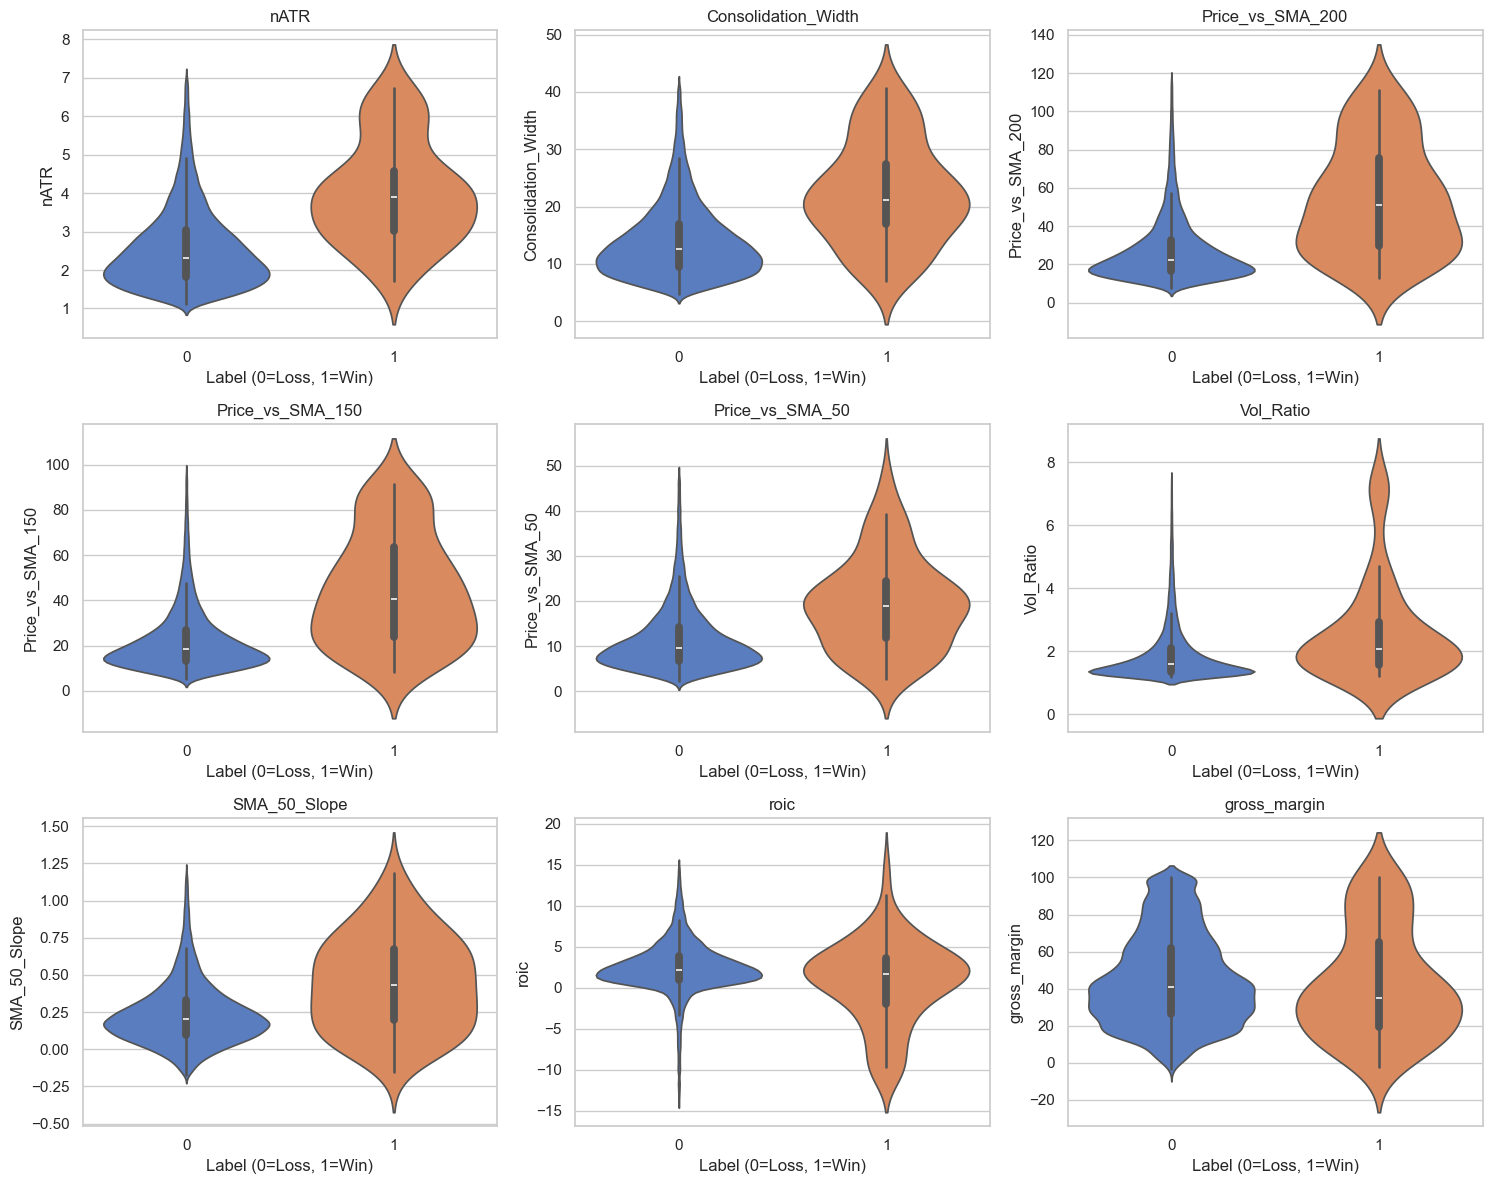

In [42]:
audit_data_quality(df)
top_features = analyze_winner_separation(df)
if top_features:
    plot_distributions(df, top_features[:9]) # Plot top 9

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

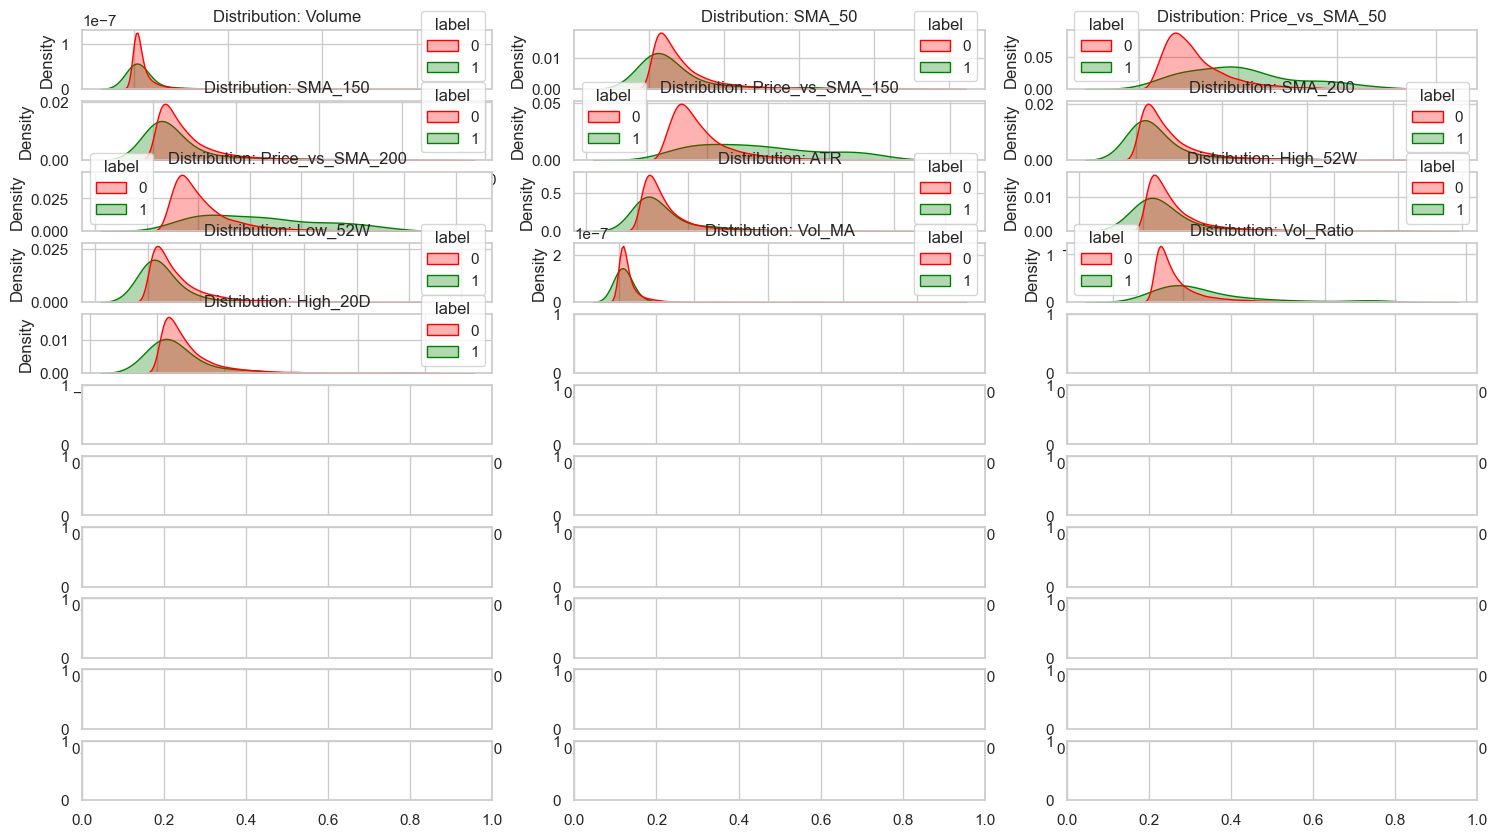

In [20]:
# ==============================================================================
# 3. VISUALIZATION
# ==============================================================================
# Set style
sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(nrows=11, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_feats):
    if i >= len(axes): break
    
    # Clip outliers for cleaner visualization (1st to 99th percentile)
    # This prevents one crazy stock from ruining the chart
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    clipped_data = df[(df[col] >= lower) & (df[col] <= upper)]
    
    # Plot KDE (Density)
    sns.kdeplot(
        data=clipped_data, x=col, hue='label', 
        fill=True, common_norm=False, palette={0: "red", 1: "green"},
        ax=axes[i], alpha=0.3
    )
    axes[i].set_title(f"Distribution: {col}")

plt.tight_layout()
plt.show()

## 1. Load Dataset B from Parquet

In [47]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Add src to path
sys.path.append(str(Path.cwd()))
from src.database import DatabaseManager

In [50]:
# Load parquet file
parquet_path = 'data/ml/dataset_a.parquet'
df = pd.read_parquet(parquet_path)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")

Total rows: 9,049

Columns: ['date', 'ticker', 'Close', 'Volume', 'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'Breakout', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'RSI_Regime', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'nATR_Lag1', 'ATR_Lag1', 'VCP_Ratio_Lag1', 'Consolidation_Width_Lag1', 'Price_vs_SMA_50_Lag1', 'Price_vs_SMA_150_Lag1', 'Price_vs_SMA_200_Lag1', 'RS_Lag1', 'RS_MA_Lag1', 'Dry_Up_Volume_Lag1', 'High_52W_Lag1', 'Low_52W_Lag1', 'RSI_14_Lag1', 'Dist_From_52W_High_Lag1', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 'alpha015', 'alpha054', 'alpha060', 'fiscal_date', 'filing_date_matched', 'fiscal_period', 'revenue_growth_yoy', 'net_income_growth_yoy', 'eps_growth_yoy', 'eps_accel', 'revenue_accel', 'inventory_grow

In [52]:
df.tail()

,date,ticker,Close,Volume,SMA_50,Price_vs_SMA_50,SMA_150,Price_vs_SMA_150,SMA_200,Price_vs_SMA_200,ATR,High_52W,Low_52W,Vol_MA,Vol_Ratio,High_20D,Breakout,RS,RS_MA,nATR,VCP_Ratio,Consolidation_Width,Dry_Up_Volume,RSI_14,RSI_Regime,Dist_From_52W_High,Is_Green_Day,Green_Days_Ratio_20D,SMA_50_Slope,nATR_Lag1,ATR_Lag1,VCP_Ratio_Lag1,Consolidation_Width_Lag1,Price_vs_SMA_50_Lag1,Price_vs_SMA_150_Lag1,Price_vs_SMA_200_Lag1,RS_Lag1,RS_MA_Lag1,Dry_Up_Volume_Lag1,High_52W_Lag1,Low_52W_Lag1,RSI_14_Lag1,Dist_From_52W_High_Lag1,alpha001,alpha006,alpha009,alpha012,alpha041,alpha101,alpha002,alpha004,alpha011,alpha013,alpha015,alpha054,alpha060,fiscal_date,filing_date_matched,fiscal_period,revenue_growth_yoy,net_income_growth_yoy,eps_growth_yoy,eps_accel,revenue_accel,inventory_growth_yoy,inventory_vs_sales_spread,symbol,reportedCurrency,cik,accepted_date,fiscalYear,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,statement_type,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid,debt_to_equity,current_ratio,quick_ratio,gross_margin,operating_margin,roe,roa,days_since_report,days_since_earnings,is_stale,has_fundamentals,pe_ratio,ps_ratio,pb_ratio,peg_adjusted,is_declining_earnings
9044,2025-11-28,AAPL,278.8500,20135620,262.639400,6.172189,229.934133,21.273860,227.191900,22.737650,5.774286,278.85,172.42,50513381.94,0.398620,277.55,True,0.408039,0.385318,2.070750,1.114214,5.400753,0.891241,66.949706,1,0.000000,1,0.60,0.288610,2.145045,5.953571,1.137634,5.426049,6.007944,20.952454,22.278419,0.408354,0.384554,0.983558,277.55,172.42,62.704115,0.000000,0.845685,0.570237,1.3000,1.3000,270.947991,0.528064,-0.339131,-8.0,0.000461,-0.458264,-1.254061,-0.9233

## 2. Check Trade ID Uniqueness

In [8]:
# Check trade_id uniqueness
trade_id_counts = df['trade_id'].value_counts()
duplicate_ids = trade_id_counts[trade_id_counts > 1]

print(f"Total trade IDs: {df['trade_id'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"Duplicate trade IDs: {len(duplicate_ids):,}")

if len(duplicate_ids) > 0:
    print(f"\n⚠️ WARNING: Found {len(duplicate_ids):,} duplicate trade IDs!")
    print(f"\nTop 10 most repeated trade IDs:")
    print(duplicate_ids.head(10))
    
    # Show example of duplicated trade_id
    example_id = duplicate_ids.index[0]
    print(f"\nExample: trade_id={example_id} appears {duplicate_ids.iloc[0]} times:")
    print(df[df['trade_id'] == example_id][['trade_id', 'ticker', 'entry_date', 'exit_date', 'entry_price', 'exit_price']])
else:
    print("✅ All trade IDs are unique")

Total trade IDs: 46,041
Total rows: 46,041
Duplicate trade IDs: 0
✅ All trade IDs are unique


## 3. Check Entry Dates vs IPO Dates

In [9]:
# Load IPO dates from database
db = DatabaseManager()
ipo_query = "SELECT ticker, ipo_date FROM company_profiles WHERE ipo_date IS NOT NULL"
ipo_dates = pd.read_sql_query(ipo_query, db.engine)
ipo_dates['ipo_date'] = pd.to_datetime(ipo_dates['ipo_date'])

print(f"IPO dates available for {len(ipo_dates):,} tickers")
ipo_dates.head()

AttributeError: 'DatabaseManager' object has no attribute 'engine'

In [5]:
# Convert entry_date to datetime
df['entry_date'] = pd.to_datetime(df['entry_date'])

# Merge with IPO dates
df_with_ipo = df.merge(ipo_dates, on='ticker', how='left')

# Find trades before IPO
df_with_ipo['days_before_ipo'] = (df_with_ipo['entry_date'] - df_with_ipo['ipo_date']).dt.days
trades_before_ipo = df_with_ipo[df_with_ipo['days_before_ipo'] < 0]

print(f"\nTrades with IPO data: {df_with_ipo['ipo_date'].notna().sum():,} / {len(df_with_ipo):,}")
print(f"Trades BEFORE IPO date: {len(trades_before_ipo):,}")

if len(trades_before_ipo) > 0:
    print(f"\n⚠️ WARNING: Found {len(trades_before_ipo):,} trades entered before IPO date!")
    print("\nTop 20 examples:")
    print(trades_before_ipo[['ticker', 'entry_date', 'ipo_date', 'days_before_ipo', 'entry_price']].sort_values('days_before_ipo').head(20))
    
    # Check OSCR specifically
    oscr_trades = df_with_ipo[df_with_ipo['ticker'] == 'OSCR']
    if len(oscr_trades) > 0:
        print("\n🔍 OSCR trades:")
        print(oscr_trades[['ticker', 'entry_date', 'ipo_date', 'entry_price', 'exit_price']].head())
else:
    print("✅ All trades entered after IPO date")

NameError: name 'ipo_dates' is not defined

## 4. Check Price Duplication Across Tickers

In [6]:
# Check entry_price duplication
price_ticker_counts = df.groupby('entry_price')['ticker'].nunique()
duplicated_prices = price_ticker_counts[price_ticker_counts > 1].sort_values(ascending=False)

print(f"Unique entry prices: {df['entry_price'].nunique():,}")
print(f"Entry prices shared by multiple tickers: {len(duplicated_prices):,}")

if len(duplicated_prices) > 0:
    print(f"\nTop 20 most shared entry prices:")
    print(duplicated_prices.head(20))
    
    # Show example
    example_price = duplicated_prices.index[0]
    print(f"\nExample: entry_price=${example_price:.2f} appears in {duplicated_prices.iloc[0]} different tickers:")
    example_trades = df[df['entry_price'] == example_price][['ticker', 'entry_date', 'entry_price', 'exit_price', 'return_pct']].head(10)
    print(example_trades)
    print(f"\nAre these prices suspicious? Check if different tickers truly had same entry price on different dates.")

Unique entry prices: 26,743
Entry prices shared by multiple tickers: 12,834

Top 20 most shared entry prices:
entry_price
20.0    29
29.0    27
10.0    25
24.0    25
14.5    25
13.0    25
15.0    24
17.0    24
36.0    24
37.0    24
16.0    23
14.0    22
23.5    22
43.0    19
16.5    19
24.5    19
9.0     19
12.0    19
18.0    19
29.5    19
Name: ticker, dtype: int64

Example: entry_price=$20.00 appears in 29 different tickers:
      ticker entry_date  entry_price  exit_price  return_pct
1874    NVRI 2003-10-13         20.0   20.020000    0.100000
3170    MMSI 2004-01-05         20.0   19.576000   -2.120000
3348     LPX 2004-01-12         20.0   20.230000    1.150000
3461     HZO 2004-01-15         20.0   22.860001   14.300005
4403    INGR 2004-03-31         20.0   20.650000    3.250000
4421     LNW 2004-04-01         20.0   21.480000    7.399998
4759     CVS 2004-05-04         20.0   20.340000    1.700000
7132    BJRI 2005-03-22         20.0   19.800000   -1.000000
12350    GEL 2007-03

In [ ]:
# Check exit_price duplication
exit_price_ticker_counts = df.groupby('exit_price')['ticker'].nunique()
duplicated_exit_prices = exit_price_ticker_counts[exit_price_ticker_counts > 1].sort_values(ascending=False)

print(f"Unique exit prices: {df['exit_price'].nunique():,}")
print(f"Exit prices shared by multiple tickers: {len(duplicated_exit_prices):,}")

if len(duplicated_exit_prices) > 0:
    print(f"\nTop 20 most shared exit prices:")
    print(duplicated_exit_prices.head(20))
    
    # Show example
    example_exit_price = duplicated_exit_prices.index[0]
    print(f"\nExample: exit_price=${example_exit_price:.2f} appears in {duplicated_exit_prices.iloc[0]} different tickers:")
    example_trades = df[df['exit_price'] == example_exit_price][['ticker', 'exit_date', 'entry_price', 'exit_price', 'return_pct']].head(10)
    print(example_trades)

## 5. Check for Exact Row Duplicates

In [ ]:
# Check for completely duplicated rows (excluding trade_id)
cols_to_check = [col for col in df.columns if col != 'trade_id']
duplicated_rows = df[df.duplicated(subset=cols_to_check, keep=False)]

print(f"Total duplicated rows (excluding trade_id): {len(duplicated_rows):,}")

if len(duplicated_rows) > 0:
    print(f"\n⚠️ WARNING: Found {len(duplicated_rows):,} duplicated rows!")
    print("\nExample of duplicated rows:")
    # Show first duplicate group
    first_dup = duplicated_rows.iloc[0]
    mask = (df[cols_to_check] == first_dup[cols_to_check]).all(axis=1)
    print(df[mask][['trade_id', 'ticker', 'entry_date', 'exit_date', 'entry_price', 'exit_price', 'return_pct']].head(10))
else:
    print("✅ No duplicate rows found")

## 6. Compare with CSV Export

In [ ]:
# Load CSV and compare
csv_path = 'data/ml/dataset_b.csv'
if Path(csv_path).exists():
    df_csv = pd.read_csv(csv_path)
    
    print(f"Parquet rows: {len(df):,}")
    print(f"CSV rows: {len(df_csv):,}")
    print(f"\nParquet columns: {list(df.columns)}")
    print(f"CSV columns: {list(df_csv.columns)}")
    
    # Check if data matches
    if len(df) != len(df_csv):
        print(f"\n⚠️ WARNING: Row count mismatch! Parquet has {len(df):,} rows, CSV has {len(df_csv):,} rows")
    else:
        print("\n✅ Row counts match")
    
    # Show first few rows from each
    print("\n--- Parquet First 3 Rows ---")
    print(df[['trade_id', 'ticker', 'entry_date', 'entry_price']].head(3))
    
    print("\n--- CSV First 3 Rows ---")
    print(df_csv[['trade_id', 'ticker', 'entry_date', 'entry_price']].head(3))
else:
    print("CSV file not found")

## 7. Data Quality Summary

In [ ]:
print("="*80)
print("DATA QUALITY SUMMARY")
print("="*80)

print(f"\n1. DATASET SIZE")
print(f"   Total rows: {len(df):,}")
print(f"   Unique tickers: {df['ticker'].nunique():,}")
print(f"   Date range: {df['entry_date'].min()} to {df['entry_date'].max()}")

print(f"\n2. TRADE ID ISSUES")
print(f"   Unique trade IDs: {df['trade_id'].nunique():,}")
print(f"   Expected: {len(df):,}")
print(f"   Duplicates: {len(duplicate_ids):,} IDs repeated")

print(f"\n3. IPO DATE ISSUES")
print(f"   Trades with IPO data: {df_with_ipo['ipo_date'].notna().sum():,}")
print(f"   Trades before IPO: {len(trades_before_ipo):,}")

print(f"\n4. PRICE DUPLICATION")
print(f"   Entry prices shared across tickers: {len(duplicated_prices):,}")
print(f"   Exit prices shared across tickers: {len(duplicated_exit_prices):,}")

print(f"\n5. ROW DUPLICATION")
print(f"   Fully duplicated rows: {len(duplicated_rows):,}")

# Overall assessment
issues = []
if len(duplicate_ids) > 0:
    issues.append("Trade ID duplication")
if len(trades_before_ipo) > 0:
    issues.append("Trades before IPO dates")
if len(duplicated_rows) > 0:
    issues.append("Fully duplicated rows")

print(f"\n{'='*80}")
if issues:
    print(f"⚠️ ISSUES FOUND: {', '.join(issues)}")
else:
    print(f"✅ NO MAJOR ISSUES DETECTED")
print(f"{'='*80}")